# Loading a dataset

One of the most basic datasets for image
recognition is the handwritten digit-recognition dataset known as MNIST. Here
we will use another dataset that is similarly simple and a bit more fun

CIFAR-10 consists of 60,000 tiny 32 × 32 color (RGB) images, labeled with an integer
corresponding to 1 of 10 classes: airplane (0), automobile (1), bird (2), cat (3),
deer (4), dog (5), frog (6), horse (7), ship (8), and truck (9).
These images are split into 50000 for training and 10000 for testing

<div style="text-align: center;">
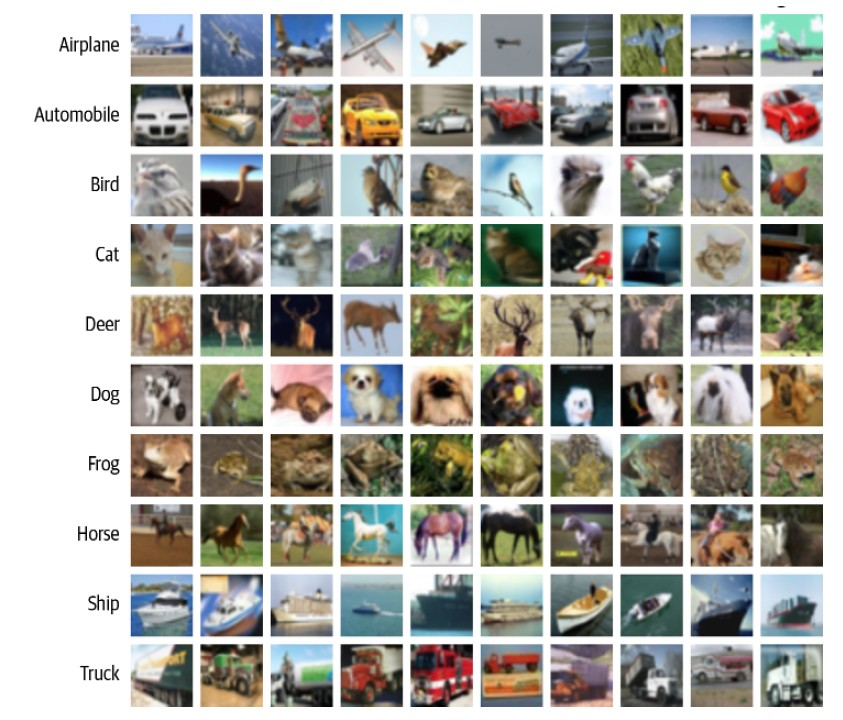
    Example images from the CIFAR-10 dataset
</div><br>

We use the torchvision module to automatically download the dataset and load it as a collection of PyTorch tensors.
This module contains a few of the best-performing neural network architectures for computer
vision but also has easy access to image classification datasets.


In [1]:
from matplotlib import pyplot as plt
import numpy as np
import torch
from torchvision import datasets
data_path = './data/cifar10/'
cifar10 = datasets.CIFAR10(data_path, train=True, download=True) 
cifar10_val = datasets.CIFAR10(data_path, train=False, download=True) 

len(cifar10), len(cifar10_val)

Files already downloaded and verified
Files already downloaded and verified


(50000, 10000)

**Comments**
* `data_path` Folder where the dataset will be stored (or loaded from if already downloaded).
* `train=True` load the training set (50000 images).
* `train=False` Loads the test set (10000 images).
* `download=True` Automatically downloads the dataset if it’s not already in data_path.

Let's see examples of the images

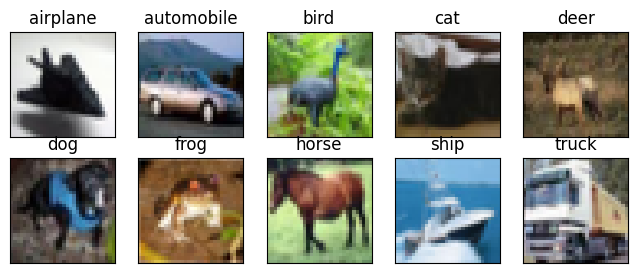

In [2]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

fig = plt.figure(figsize=(8,3))
num_classes = 10
for i in range(num_classes):
    ax = fig.add_subplot(2, 5, 1 + i, xticks=[], yticks=[])
    ax.set_title(class_names[i])
    img = next(img for img, label in cifar10 if label == i)
    plt.imshow(img)
plt.show()

`cifar10` is a PyTorch Dataset object that when interrogated like a list and returns an image and a label.

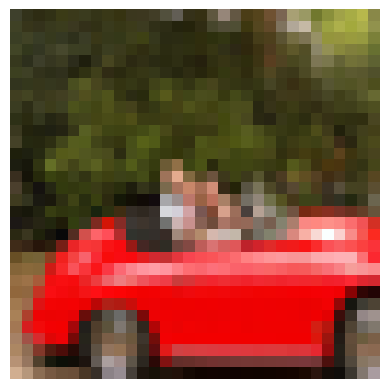

1

In [3]:
img, label = cifar10[99]
plt.imshow(img)
plt.axis('off')
plt.show()
label


What we get a PIL (Python Imaging Library, the PIL package) `image` with a `label`, an
integer with the value 1, corresponding to “automobile”

## Exercise

* which other datasets are available in torchvision?
* plot a japanese character

# Transforming images

we’ll likely need a way to convert the PIL image to a PyTorch
tensor before we can do anything with it. That’s where torchvision.transforms
comes in. This module defines a set of composable, function-like objects that can be
passed as an argument to a torchvision dataset such as datasets.CIFAR10(…), and
that perform transformations on the data after it is loaded


In [4]:
from torchvision import transforms
dir(transforms)

['AugMix',
 'AutoAugment',
 'AutoAugmentPolicy',
 'CenterCrop',
 'ColorJitter',
 'Compose',
 'ConvertImageDtype',
 'ElasticTransform',
 'FiveCrop',
 'GaussianBlur',
 'Grayscale',
 'InterpolationMode',
 'Lambda',
 'LinearTransformation',
 'Normalize',
 'PILToTensor',
 'Pad',
 'RandAugment',
 'RandomAdjustSharpness',
 'RandomAffine',
 'RandomApply',
 'RandomAutocontrast',
 'RandomChoice',
 'RandomCrop',
 'RandomEqualize',
 'RandomErasing',
 'RandomGrayscale',
 'RandomHorizontalFlip',
 'RandomInvert',
 'RandomOrder',
 'RandomPerspective',
 'RandomPosterize',
 'RandomResizedCrop',
 'RandomRotation',
 'RandomSolarize',
 'RandomVerticalFlip',
 'Resize',
 'TenCrop',
 'ToPILImage',
 'ToTensor',
 'TrivialAugmentWide',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_functional_pil',
 '_functional_tensor',
 '_presets',
 'autoaugment',
 'functional',
 'transforms']

### Common useful transforms

*Basic*
* ToTensor() converts PIL image to PyTorch tensor
* Normalize(mean, std) normalize pixel values

*Resizing / cropping*
* Resize(size)
* CenterCrop(size)
* RandomCrop(size)
* RandomResizedCrop(size)

*Data augmentation*
* RandomHorizontalFlip()
* RandomRotation(degrees)
* ColorJitter(...)
* RandomGrayscale()


## Exercise
Experiment with some of these transforms and plot the results

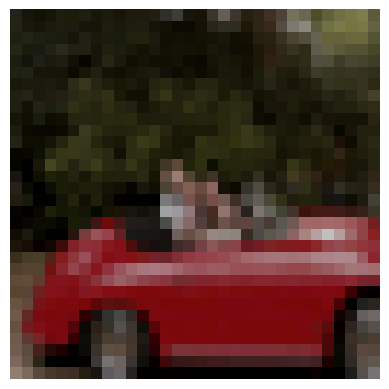

In [5]:
img, label = cifar10[99]
change=transforms.ColorJitter(
        brightness=0.5,
        contrast=0.5,
        saturation=0.5,
        hue=0.1)
plt.imshow(change(img))
plt.axis('off')
plt.show()
    

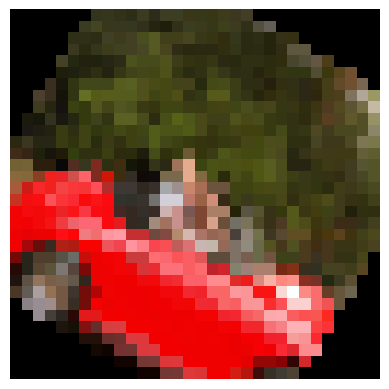

In [6]:
img, label = cifar10[99]
change=transforms.RandomRotation(50)
plt.imshow(change(img))
plt.axis('off')
plt.show()


Among those transforms, we can spot ToTensor, which turns NumPy arrays and PIL
images to tensors. It also takes care to lay out the dimensions of the output tensor as
C × H × W (channel, height, width; just as we covered in chapter 4).
Let’s try out the ToTensor transform. Once instantiated, it can be called like a
function with the PIL image as the argument, returning a tensor as output

In [7]:
img, label = cifar10[99]
to_tensor = transforms.ToTensor()
img_t = to_tensor(img)
img_t.shape

torch.Size([3, 32, 32])

As we anticipated, we can pass the transform directly as an argument to dataset
.CIFAR10:

In [8]:
tensor_cifar10 = datasets.CIFAR10(data_path, train=True, download=False,
                          transform=transforms.ToTensor())

In [9]:
img_t, _ = tensor_cifar10[99]
type(img_t)

torch.Tensor

Whereas the values in the original PIL image ranged from 0 to 255 (8 bits per channel),
the ToTensor transform turns the data into a 32-bit floating-point per channel,
scaling the values down from 0.0 to 1.0

In [10]:
img_t.min(), img_t.max()

(tensor(0.), tensor(1.))

# Normalising the input

Transforms are really handy because we can chain them using transforms. Compose,
and they can handle normalization and data augmentation transparently, directly in
the data loader. For instance, it’s good practice to normalize the dataset so that each
channel has zero mean and unitary standard deviation. We mentioned this in chapter
4, but now, after going through chapter 5, we also have an intuition for why: by choosing
activation functions that are linear around 0 plus or minus 1 (or 2), keeping the data
in the same range means it’s more likely that neurons have nonzero gradients


In [11]:
imgs = torch.stack([img_t for img_t, _ in tensor_cifar10], dim=3)
imgs.shape

torch.Size([3, 32, 32, 50000])

In [12]:
imgs.view(3, -1).mean(dim=1)  

tensor([0.4914, 0.4822, 0.4465])

Recall that view(3, -1) keeps the three channels and
merges all the remaining dimensions into one, figuring
out the appropriate size. Here our 3 × 32 × 32 image is
transformed into a 3 × 1,024 vector, and then the mean
is taken over the 1,024 elements of each channel

In [13]:
imgs.view(3, -1).std(dim=1)

tensor([0.2470, 0.2435, 0.2616])

In [14]:
transforms.Normalize((0.4915, 0.4823, 0.4468), (0.2470, 0.2435, 0.2616))

Normalize(mean=(0.4915, 0.4823, 0.4468), std=(0.247, 0.2435, 0.2616))

In order to make it so that each channel has zero mean and unitary standard deviation,
we can compute the mean value and the standard deviation of each channel
across the dataset and apply the following transform: v_n[c] = (v[c] - mean[c]) /
stdev[c]. This is what transforms.Normalize does. The values of mean and stdev
must be computed offline (they are not computed by the transform).

In [15]:
transformed_cifar10 = datasets.CIFAR10(
    data_path, train=True, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ]))

transformed_cifar10_val = datasets.CIFAR10(
    data_path, train=False, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ]))

The renormalized red car we get is shown in figure 7.5. This is because normalization
has shifted the RGB levels outside the 0.0 to 1.0 range and changed the overall magnitudes
of the channels. All of the data is still there; it’s just that Matplotlib renders it as
black

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9806982..2.126078].


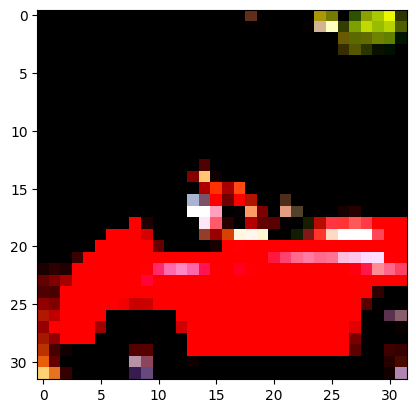

In [16]:
img_t, _ = transformed_cifar10[99]
plt.imshow(img_t.permute(1, 2, 0))
plt.show()

# First classification task

We’ll pick out all the birds and airplanes from our CIFAR-10 dataset and build a neural network that can tell birds and airplanes apar

just filter the data in cifar10 and remap the labels so they are contiguous

In [18]:
label_map = {0: 0, 2: 1}
class_names = ['airplane', 'bird']
cifar2 = [(img, label_map[label])
          for img, label in transformed_cifar10 
          if label in [0, 2]]
cifar2_val = [(img, label_map[label])
              for img, label in transformed_cifar10_val
              if label in [0, 2]]

# save for later use in file cifar2.pt
torch.save({
    "cifar2": cifar2,
    "cifar2_val": cifar2_val,
    "class_names": class_names}, "./data/cifar2.pt")


## A fully connected model

After all, an image is just a set of numbers laid out
in a spatial configuration. OK, we don’t know how to handle the spatial configuration
part just yet, but in theory if we just take the image pixels and straighten them into a
long 1D vector, we could consider those numbers as input features, right? This is what
figure 7.7 illustrates.
Let’s try that. How many features per sample? Well, 32 × 32 × 3: that is, 3,072 input
features per sample. Starting from the model we built in chapter 5, our new model
would be an nn.Linear with 3,072 input features and some number of hidden features

<div style="text-align: center;">
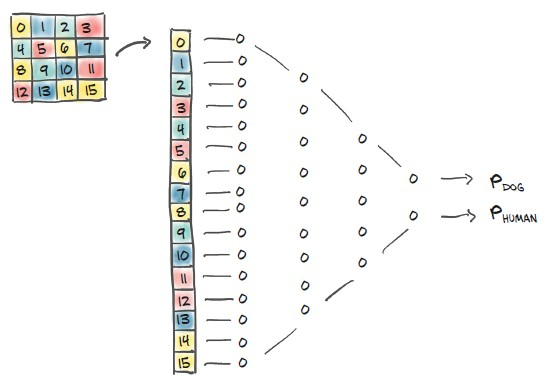
    Fully connected model for classification
</div>

We somewhat arbitrarily pick 512 hidden features. A neural network needs at least
one hidden layer (of activations, so two modules)


In [18]:
import torch.nn as nn

model = nn.Sequential(
            nn.Linear(3072, 512),
            nn.Tanh(),
            nn.Linear(512, 2))

## Probabilities as output 

We need to recognize that the output is categorical: it’s either a bird or an airplane
(or something else if we had all 10 of the original classes). As we learned in
chapter 4, when we have to represent a categorical variable, we should switch to a
one-hot-encoding representation of that variable, such as [1, 0] for airplane or [0, 1]

for bird (the order is arbitrary). This will still work if we have 10 classes, as in the full
CIFAR-10 dataset; we’ll just have a vector of length 10.6
In the ideal case, the network would output torch.tensor([1.0, 0.0]) for an airplane
and torch.tensor([0.0, 1.0]) for a bird. Practically speaking, since our classifier
will not be perfect, we can expect the network to output something in between.
The key realization in this case is that we can interpret our output as probabilities

Casting the problem in terms of probabilities imposes a few extra constraints on
the outputs of our network:
1. Each element of the output must be in the [0.0, 1.0] range (a probability of
an outcome cannot be less than 0 or greater than 1).
2. The elements of the output must add up to 1.0 (we’re certain that one of the
two outcomes will occur).

It sounds like a tough constraint to enforce in a differentiable way on a vector of numbers.
Yet there’s a very smart trick that does exactly that, and it’s differentiable: it’s
called ``softmax``.

$$
\text{softmax}(x_1,x_2) = \left(\frac{e^{x_1}}{e^{x_1}+e^{x_2}}, \frac{e^{x_2}}{e^{x_1}+e^{x_2}} \right)
$$

$$
\text{softmax}(x_1,\cdots, x_n) = \left(\frac{e^{x_1}}{e^{x_1}+\cdots +e^{x_n}}, \cdots, \frac{e^{x_n}}{e^{x_1}+\cdots +e^{x_n}} \right)
$$




In [19]:
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum()

x = torch.tensor([1.0, 2.0, 3.0])
softmax(x)

tensor([0.0900, 0.2447, 0.6652])

The nn module makes softmax available as a module. Since, as usual, input tensors
may have an additional batch 0th dimension, or have dimensions along which they
encode probabilities and others in which they don’t, ``nn.Softmax`` requires us to specify
the dimension along which the softmax function is applied:

In [20]:
model = nn.Sequential(
            nn.Linear(3072, 512),
            nn.Tanh(),
            nn.Linear(512, 2),
            nn.Softmax(dim=1))

Let's see what we get with ``cifar2[0]`` which is the image of a bird

In [21]:
img, _ = cifar2[0]
img_batch = img.view(-1).unsqueeze(0)
out = model(img_batch)
out

tensor([[0.5112, 0.4888]], grad_fn=<SoftmaxBackward0>)

So, we got probabilities! Well, we know we shouldn’t get too excited: the weights and
biases of our linear layers have not been trained at all. Their elements are initialized
randomly by PyTorch between –1.0 and 1.0. 
If the labels are provided as index 0 for “airplane” and index 1 for “bird”, then that’s the order the outputs will be induced to take. Thus,
after training, we will be able to get the label as an index by computing the argmax of
the output probabilities: that is, the index at which we get the maximum probability
The computed probability is larger for the second entry. It says the image is a bird. Pure luck

## A loss for classifying

It makes littl sense in using the mean square error (MSE) as our loss.
In other words, we want a loss function that
is very high when the likelihood is low: so low that the alternatives have a higher probability.
Conversely, the loss should be low when the likelihood is higher than the alternatives,
and we’re not really fixated on driving the probability up to 1.
There’s a loss function that behaves that way, and it’s called negative log likelihood
(NLL)
$$
\text{NLL} = - \sum_i^N(\log(out_i[c_i]))
$$
where the sum is taken over N samples and c_i is the correct class for sample i.

Summing up, our loss for classification can be computed as follows. For each sample
in the batch:
1. Run the forward pass, and obtain the output values from the last (linear) layer.
2. Compute their softmax, and obtain probabilities.
3. Take the predicted probability corresponding to the correct class (the likelihood
of the parameters). Note that we know what the correct class is because
it’s a supervised problem—it’s our ground truth.
4. Compute its logarithm, put a minus sign in front of it, and add it to the loss.


<div style="text-align: center;">
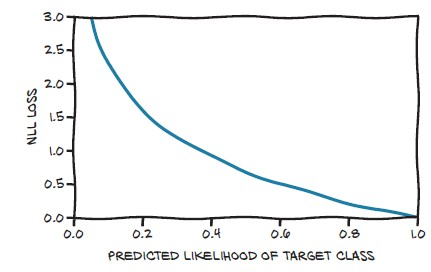
    NLL loss
</div>

PyTorch has an nn.NLLLoss class. However (gotcha
ahead), as opposed to what you might expect, it does not take probabilities but rather
takes a tensor of log probabilities as input. It then computes the NLL of our model
given the batch of data.
As taking the logarithm of a probability is tricky when the probability gets close to zero, it's better to use the 
``nn.LogSoftmax`` instead of ``nn.Softmax``



In [22]:
model = nn.Sequential(
            nn.Linear(3072, 512),
            nn.Tanh(),
            nn.Linear(512, 2),
            nn.LogSoftmax(dim=1))

loss = nn.NLLLoss()

## Training the classifier

We’re ready to bring back the training loop we wrote in earlier sessions and see how it trains


In [23]:
import torch
import torch.nn as nn
import torch.optim as optim

model = nn.Sequential(
            nn.Linear(3072, 512),
            nn.Tanh(),
            nn.Linear(512, 2),
            nn.LogSoftmax(dim=1))

learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.NLLLoss()
#n_epochs = 100
n_epochs = 10

for epoch in range(n_epochs):
    for img, label in cifar2:
        out = model(img.view(-1).unsqueeze(0))
        loss = loss_fn(out, torch.tensor([label]))
                
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

Epoch: 0, Loss: 4.315768
Epoch: 1, Loss: 7.098890
Epoch: 2, Loss: 5.148107
Epoch: 3, Loss: 8.694939
Epoch: 4, Loss: 9.533424
Epoch: 5, Loss: 6.673620
Epoch: 6, Loss: 8.139387
Epoch: 7, Loss: 8.146568
Epoch: 8, Loss: 11.048287
Epoch: 9, Loss: 5.151557


## Training with batches

Looking more closely, we made a small change to the training loop. Earlier, we
had just one loop: over the epochs (recall that an epoch ends when all samples in the
training set have been evaluated). We figured that evaluating all 10,000 images in a
single batch would be too much, so we decided to have an inner loop where we evaluate
one sample at a time and backpropagate over that single sample.

While in the first case the gradient is accumulated over all samples before being
applied, in this case we apply changes to parameters based on a very partial estimation.

of the gradient on a single sample. However, what is a good direction for reducing the
loss based on one sample might not be a good direction for others. By shuffling samples
at each epoch and estimating the gradient on one or (preferably, for stability) a few
samples at a time, we are effectively introducing randomness in our gradient descent.
Remember SGD? It stands for stochastic gradient descent, and this is what the S is about:
working on small batches (aka minibatches) of shuffled data


In [24]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=True)

Typically, minibatches are a constant size that we need to set prior to training, just
like the learning rate. These are called hyperparameters, to distinguish them from the
parameters of a model. The ``torch.utils.data`` module has a class that helps with shuffling and
organizing the data in minibatches: ``DataLoader``. The job of a data loader is to sample
minibatches from a dataset, giving us the flexibility to choose from different sampling
strategies. A very common strategy is uniform sampling after shuffling the data at each
epoch.

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=True)

model = nn.Sequential(
            nn.Linear(3072, 128),
            nn.Tanh(),
            nn.Linear(128, 2),
            nn.LogSoftmax(dim=1))

learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.NLLLoss()
#n_epochs = 100
n_epochs = 10

for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        outputs = model(imgs.view(imgs.shape[0], -1))
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

Epoch: 0, Loss: 0.481368
Epoch: 1, Loss: 0.295969
Epoch: 2, Loss: 0.454934
Epoch: 3, Loss: 0.323408
Epoch: 4, Loss: 0.479697
Epoch: 5, Loss: 0.292302
Epoch: 6, Loss: 0.493021
Epoch: 7, Loss: 0.298529
Epoch: 8, Loss: 0.410680
Epoch: 9, Loss: 0.350411


We see that the loss decreases somehow, but we have no idea whether it’s low enough.
Since our goal here is to correctly assign classes to images, and preferably do that on
an independent dataset, we can compute the accuracy of our model on the validation
set in terms of the number of correct classifications over the total:

In [26]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in train_loader:
        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())
        
print("Accuracy: %f" % (correct / total))

Accuracy: 0.847500


Not a great performance, but quite a lot better than random. In our defense, our
model was quite a shallow classifier; it’s a miracle that it worked at all. It did because
our dataset is really simple—a lot of the samples in the two classes likely have systematic
differences (such as the color of the background) that help the model tell birds
from airplanes, based on a few pixels

We can certainly add some bling to our model by including more layers, which will
increase the model’s depth and capacity. One rather arbitrary possibility is.
It is quite common to drop the last nn.LogSoftmax layer from the network and use
nn.CrossEntropyLoss as a loss. Let us try that

In [27]:
model = nn.Sequential(
            nn.Linear(3072, 1024),
            nn.Tanh(),
            nn.Linear(1024, 512),
            nn.Tanh(),
            nn.Linear(512, 128),
            nn.Tanh(),
            nn.Linear(128, 2))

loss_fn = nn.CrossEntropyLoss()

Here we are trying to taper the number of features more gently toward the output, in
the hope that intermediate layers will do a better job of squeezing information in
increasingly shorter intermediate outputs.
The combination of ``nn.LogSoftmax`` and ``nn.NLLLoss`` is equivalent to using
``nn.CrossEntropyLoss``

To add to the confusion, in information theory, up to normalization by sample size,
this cross entropy can be interpreted as a negative log likelihood of the predicted distribution
under the target distribution as an outcome

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=True)

model = nn.Sequential(
            nn.Linear(3072, 1024),
            nn.Tanh(),
            nn.Linear(1024, 512),
            nn.Tanh(),
            nn.Linear(512, 128),
            nn.Tanh(),
            nn.Linear(128, 2))

learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()
#n_epochs = 100
n_epochs = 10

for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        outputs = model(imgs.view(imgs.shape[0], -1))
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

### Exercice 

Run the new model.
Training this model and evaluating the accuracy on the validation set (0.802000)
lets us appreciate that a larger model bought us an increase in accuracy, but not that
much. The accuracy on the training set is practically perfect (0.998100). What is this
telling us? That we are overfitting our model in both cases

## Number of parameters

PyTorch offers a quick way to determine how many parameters a model has through the ``parameters()`` method of ``nn.Model`` (the same method we use to provide
the parameters to the optimizer). To find out how many elements are in each tensor instance, we can call the ``numel`` method

In [30]:
numel_list = [p.numel()
              for p in model.parameters()
              if p.requires_grad == True]
sum(numel_list), numel_list

(3737474, [3145728, 1024, 524288, 512, 65536, 128, 256, 2])

# Limits

It’s like taking every single input value—that is, every single component in our RGB image—and computing a linear combination of it with all the
other values for every output feature. On one hand, we are allowing for the combination of any pixel with every other pixel in the image being potentially relevant for our task. On the other hand, we aren’t utilizing the relative position of neighboring or faraway pixels, since we are treating the image as one big vector of numbers

However, shift the same airplane by one pixel or more as in the bottom half of the figure, and the relationships between pixels will have to be relearned from scratch: this time, an airplane is likely when pixel 0,2 is dark, pixel 1,2 is dark, and so on. In more technical terms, **a fully connected network is not translation invariant**. This means a network that has been trained to recognize a Spitfire starting at position 4,4 will not
be able to recognize the exact same Spitfire starting at position 8,8.

We would then have to **augment** the dataset—that is, apply random translations to images during training— so the network would have a chance to see Spitfires all over the image, and we would need to do this for every image in the dataset

However, this data augmentation strategy comes at a cost: the number of hidden features—that is, of parameters—must be large enough to store the information about all of these translated replicas